{'poem': '《咏莲》\n玉立亭亭水中央，淤泥不染自生香。\n风摇翠盖珠玑落，月照禅心诗韵长。\n\n赏析：这首作品以莲花为吟咏对象，通过“玉立亭亭”、“淤泥不染”等生动描绘，展现了莲花高洁清雅的姿态。后两句以“风摇翠盖”、“月照禅心”营造出空灵意境，将莲之物理特性与禅意相融，既暗合佛教圣花之寓意，又赋予其超然物外的精神气质，体现了对高洁品格的向往与礼赞。', 'joke': '这里为您准备了一些关于莲花的笑话，从谐音梗到生活哲理，希望能博您一笑：\n\n**1. 谐音梗篇（最冷）**\n莲花和梅花聊天。\n梅花说：“都说我们花中君子，我盛开在寒冬，傲雪凌霜，厉害吧？”\n莲花点点头：“我虽然盛开在盛夏，但我每天泡在水里，所以我懂‘泡’学，你懂吗？”\n梅花问：“什么泡学？”\n莲花说：“就是‘出淤泥而不染’——意思是我天天泡在水里，但从来没洗过澡，也不脏，这叫‘佛系泡澡’。”\n梅花：“……”\n\n**2. 语文课篇**\n老师问：“同学们，有谁知道‘出淤泥而不染’是什么意思？”\n小明举手：“老师，这我知道！就是莲花在泥巴里长大，但洗个澡就白白了，而且它洗澡用的是天然矿泉水——雨水！”\n老师（扶眼镜）：“那‘濯清涟而不妖’呢？”\n小明：“就是它洗完澡也不化妆，素颜出门，所以是‘清水出芙蓉’！”\n老师：“……你出去站着，让莲花静静。”\n\n**3. 生活哲理篇**\n莲花对荷叶抱怨：“唉，天天被人拍照，说我是‘花中君子’，压力好大。”\n荷叶安慰它：“别想太多，大家夸你，是因为你站得高。”\n莲花：“我站得高是因为我有长长的茎，这不是‘拼爹’，这是‘拼茎’（经）历！”\n荷叶：“……”\n莲花：“而且，你没发现吗？我虽然开得漂亮，但我从不‘招蜂引蝶’——那是因为我的花粉有毒，这叫‘高冷’。”\n荷叶：“……你这不是高冷，你是不让蜜蜂‘采蜜’（踩你）。”\n\n**4. 方言误会篇**\n有个北方人第一次去南方看荷花，赞叹道：“这荷叶真大！”\n旁边南方老太太说：“对咯，这是‘莲蓬’（连连碰）。”\n北方人一听，以为要碰他，赶紧躲开：“大姨，我没碰你！”\n老太太乐了：“我是说，这个‘莲蓬’（连碰）是吃的，你别乱跑，小心‘藕断丝连’（偶断丝连）——你踩断藕，我们可就‘连’在一起了！”\n\n**5. 终极冷段子**\n为什么莲花从来不和玫瑰、牡丹一起

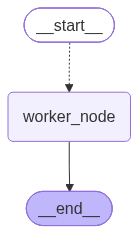

In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Sequence
from IPython.display import display
from langchain_deepseek import ChatDeepSeek
from dotenv import load_dotenv
from loguru import logger
from langgraph.types import Send
from langchain.messages import HumanMessage, AIMessage, SystemMessage
load_dotenv(override=True)
CONTENT_TYPES= ["poem","joke", "ci_poem" ]

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    # temperature=0.7,
    extra_body={
        "thinking": {
            "type": "disabled",
        }
    }
)

class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    ci_poem: str
    content_type: str

class workerState(TypedDict):
    content_type: Literal["poem","joke", "ci_poem" ]
    prompt: str

class inputState(TypedDict):
    topic: str

class outputState(TypedDict):
    poem: str
    joke: str
    ci_poem: str

def worker_node(state: workerState) -> outputState:
    content_type = state["content_type"]
    prompt = state["prompt"]
    content = model.invoke([HumanMessage(prompt)]).content
    return {
        content_type: content,
    }

def router(state: inputState) -> Sequence[Send]:
    router_prompt = "请生成关于{}的{}"
    english2Chinese = {
        "poem": "七言绝句",
        "joke": "笑话",
        "ci_poem": "中文宋词",
    }
    topic = state["topic"]
    return [
        Send(
            "worker_node",
            {
                "content_type": content_type,
                "prompt": router_prompt.format(topic,
                                english2Chinese[content_type])
            }
        )
        for content_type in CONTENT_TYPES
    ]

builder = StateGraph(state_schema=OverAllState, input_schema=inputState, output_schema=outputState)

builder.add_node("worker_node",worker_node)
builder.add_conditional_edges(
    START,
    router,
    path_map=["worker_node"]
)

builder.add_edge("worker_node", END)
graph = builder.compile()
res = graph.invoke({"topic": "莲花"})
print(res)

display(graph)
